CREATING MACHINE ELARNING MODELS


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns="Potability")
y = df["Potability"]

# Keep test data completely separate
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    random_state=42
)

# Validation through cross-validation
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

# Train final model on all training data
model.fit(X_train, y_train)

# Final evaluation
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

In [3]:
import pandas as pd
from pathlib import Path

In [4]:
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from ETL.EXTRACT import Extraction

p = Path.cwd().parent.parent  /"DATASET"/"water_potability.csv"

df = Extraction(p).extract_data()

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [8]:


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)




# ============================================================
# 2. FEATURES AND TARGET
# ============================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. IMPUTATION
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# ============================================================
# 5. CREATE RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    class_weight="balanced",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 6. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy  : 0.643
Precision : 0.562
Recall    : 0.391
F1 Score  : 0.461

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.81      0.73       400
           1       0.56      0.39      0.46       256

    accuracy                           0.64       656
   macro avg       0.62      0.60      0.60       656
weighted avg       0.63      0.64      0.63       656


Confusion Matrix:
[[322  78]
 [156 100]]


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    class_weight="balanced",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    }
)

print("Accuracy :", scores["test_accuracy"].mean())
print("Precision:", scores["test_precision"].mean())
print("Recall   :", scores["test_recall"].mean())
print("F1       :", scores["test_f1"].mean())

Accuracy : 0.6529352075963508
Precision: 0.5719383747485064
Recall   : 0.45149816176470586
F1       : 0.5034298954639777


In [10]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)




# ============================================================
# 2. FEATURES AND TARGET
# ============================================================

X = df.drop("Potability", axis=1)
y = df["Potability"]


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. PIPELINE
# ============================================================

pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])


# ============================================================
# 5. HYPERPARAMETER SEARCH SPACE
# ============================================================

param_dist = {

    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        None
    ],

    "model__class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ]
}


# ============================================================
# 6. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 7. RANDOMIZED SEARCH
# ============================================================

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# ============================================================
# 8. TRAIN RANDOMIZED SEARCH
# ============================================================

random_search.fit(X_train, y_train)


# ============================================================
# 9. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(random_search.best_params_)


# ============================================================
# 10. BEST CROSS-VALIDATION SCORE
# ============================================================

print("\nBest CV F1 Score:")
print(random_search.best_score_)


# ============================================================
# 11. BEST MODEL
# ============================================================

best_model = random_search.best_estimator_


# ============================================================
# 12. TEST SET PREDICTIONS
# ============================================================

y_pred = best_model.predict(X_test)


# ============================================================
# 13. TEST SET EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nTest Set Results:")
print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 8, 'model__max_features': None, 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1 Score:
0.5655423531714988

Test Set Results:
Accuracy  : 0.643
Precision : 0.547
Recall    : 0.500
F1 Score  : 0.522

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       400
           1       0.55      0.50      0.52       256

    accuracy                           0.64       656
   macro avg       0.62      0.62      0.62       656
weighted avg       0.64      0.64      0.64       656


Confusion Matrix:
[[294 106]
 [128 128]]


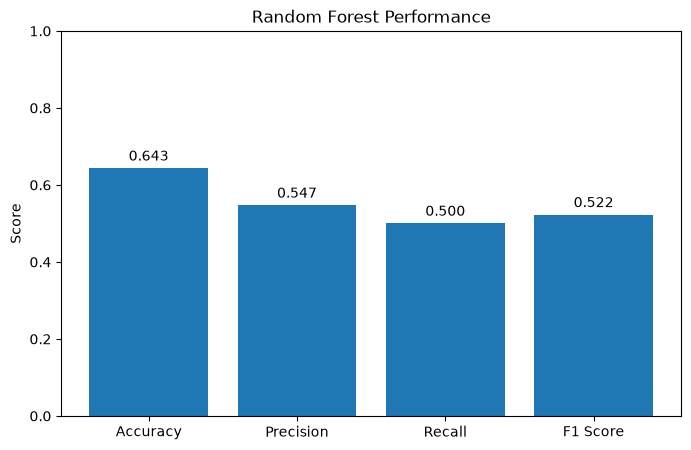

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


# Store metrics
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}


# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.title("Random Forest Performance")
plt.ylabel("Score")

# Add values above bars
for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()